In [ ]:
import os
os.environ["JAVA_HOME"] = "/opt/conda/envs/py38" # change path as needed

# Imports

In [19]:
import os
import sys
import glob
import json
import math
import time
import pdb
import pandas as pd
import numpy as np
from tqdm import tqdm
from matplotlib import pyplot as plt
from matplotlib import cm
import matplotlib as mpl
from pathlib import Path
from pathml.core import HESlide
%load_ext autoreload
%autoreload 2

sys.path.append('/mnt/scripts/biliseq_he_class2')
from helpers import anno as annoHelper

model_path = Path('/mnt/data/biliseq_he_class/models')
results = Path('/mnt/results')
sampleinfo = Path('/mnt/sampleinfo')
v6_path=Path('/mnt/data/biliseq_he_class/proc/v6/') #flatten to /mnt/data/proc/v6
tiles_path=v6_path.joinpath('tiles') # this should be updated to tiles_500px!
raw = Path('/mnt/data/biliseq_he_class/raw/new_data_20220829') #When all the wrinkles are worked out, flatten to /mnt/data/raw
svs = [str(x.parts[-1]) for x in raw.glob('*.svs')]
anno = Path('/mnt/data/biliseq_he_class/annotations/') #result? sampleinfo? flatten
# info = pd.read_csv(sampleinfo.joinpath('new_data_20220829_diagnosis_data_with_anno_v2.tsv'),
#                                       sep = '\t')

info = pd.read_csv(sampleinfo.joinpath('new_data_20220829_diagnosis_data_438_with_anno_v4.tsv'),
                                      sep = '\t')
old_info = pd.read_csv(sampleinfo.joinpath('run0_new_data_20220829_diagnosis_data.tsv'),
                  sep = '\t')
ai = pd.read_csv(sampleinfo.joinpath('annotated_fns_v2.tsv'), sep = '\t')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Helpers
See: /helpers/anno.py

# Plot all QuPath annotations

In [39]:
anno_types = [x['properties']['classification']['name'] \
                            for x in allobjects['features'] \
                            if 'classification' in x['properties'].keys()]
np.any(pd.Series(anno_types).isin(['Tumor','Malignant']).values)

True

['Benign Bile Duct' 'Malignant']


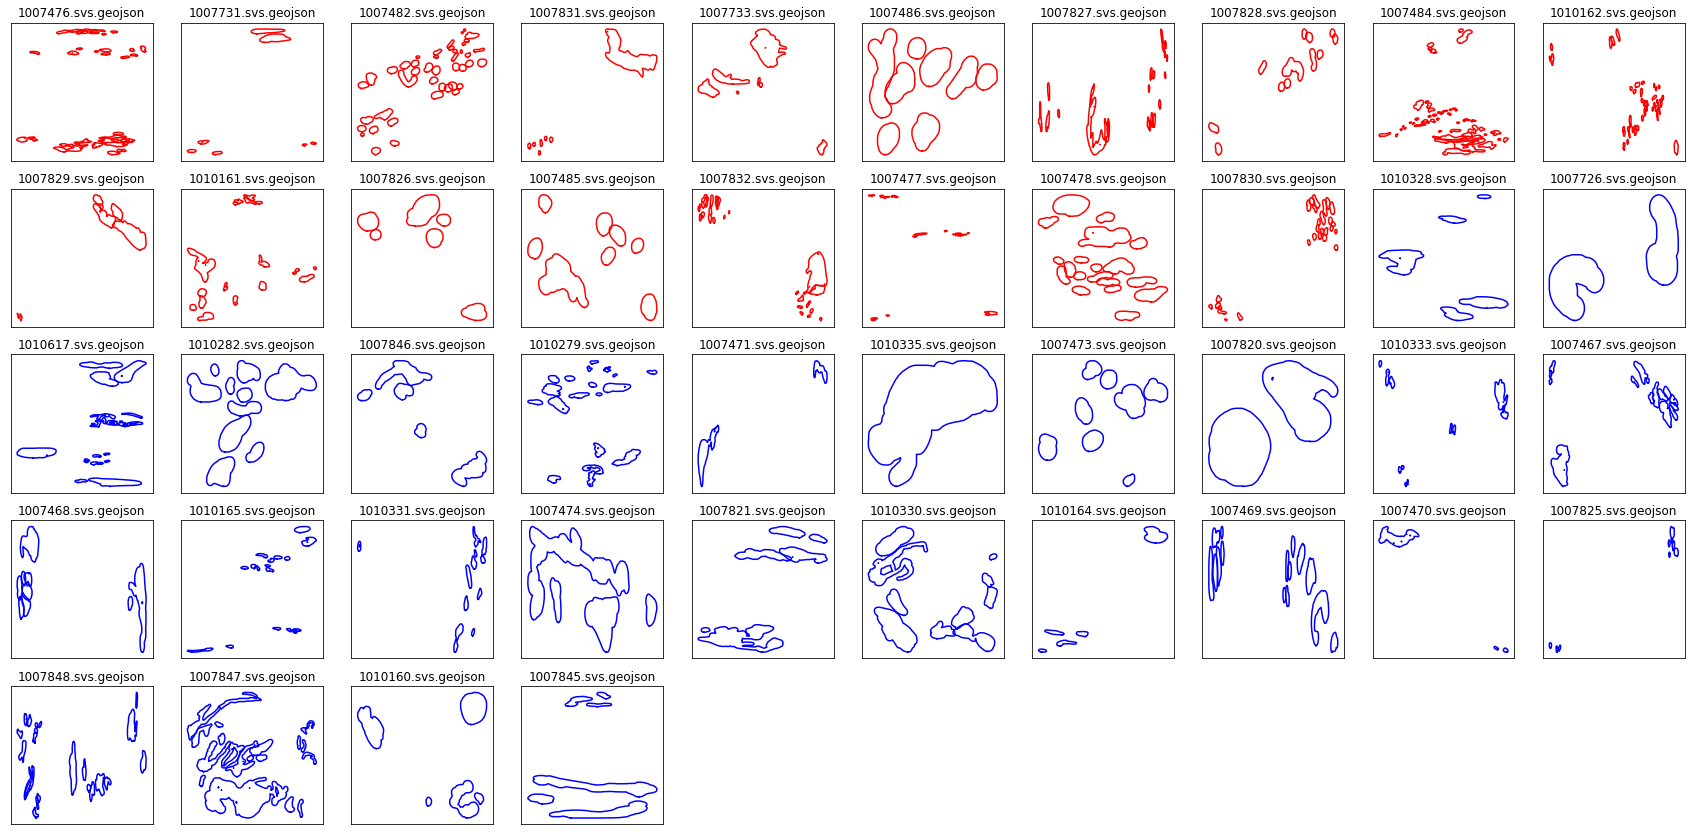

In [69]:
fig = plt.figure(figsize=(30,30))
i = 1
all_class = []
gjsons = [x for x in anno.rglob('*.geojson')]
for json_fname in gjsons:
    with open(json_fname) as f:
        allobjects = json.load(f) #
    ax = fig.add_subplot(10,10,i)
    ax.set_title(json_fname.parts[-1])
    for feat in allobjects['features']:
        plot_geojson_feature(feat,ax)
        plt.xticks([])
        plt.yticks([])
    i = i + 1
print(np.unique(all_class))
# plt.savefig(anno.joinpath('aatur_qupath_annotations_asof_090722.png'))
# plt.savefig(results.joinpath('aatur_qupath_annotations_asof_090722.png'))


# Plot new annotations (December 2022)

No annotation class found (Green)
[]


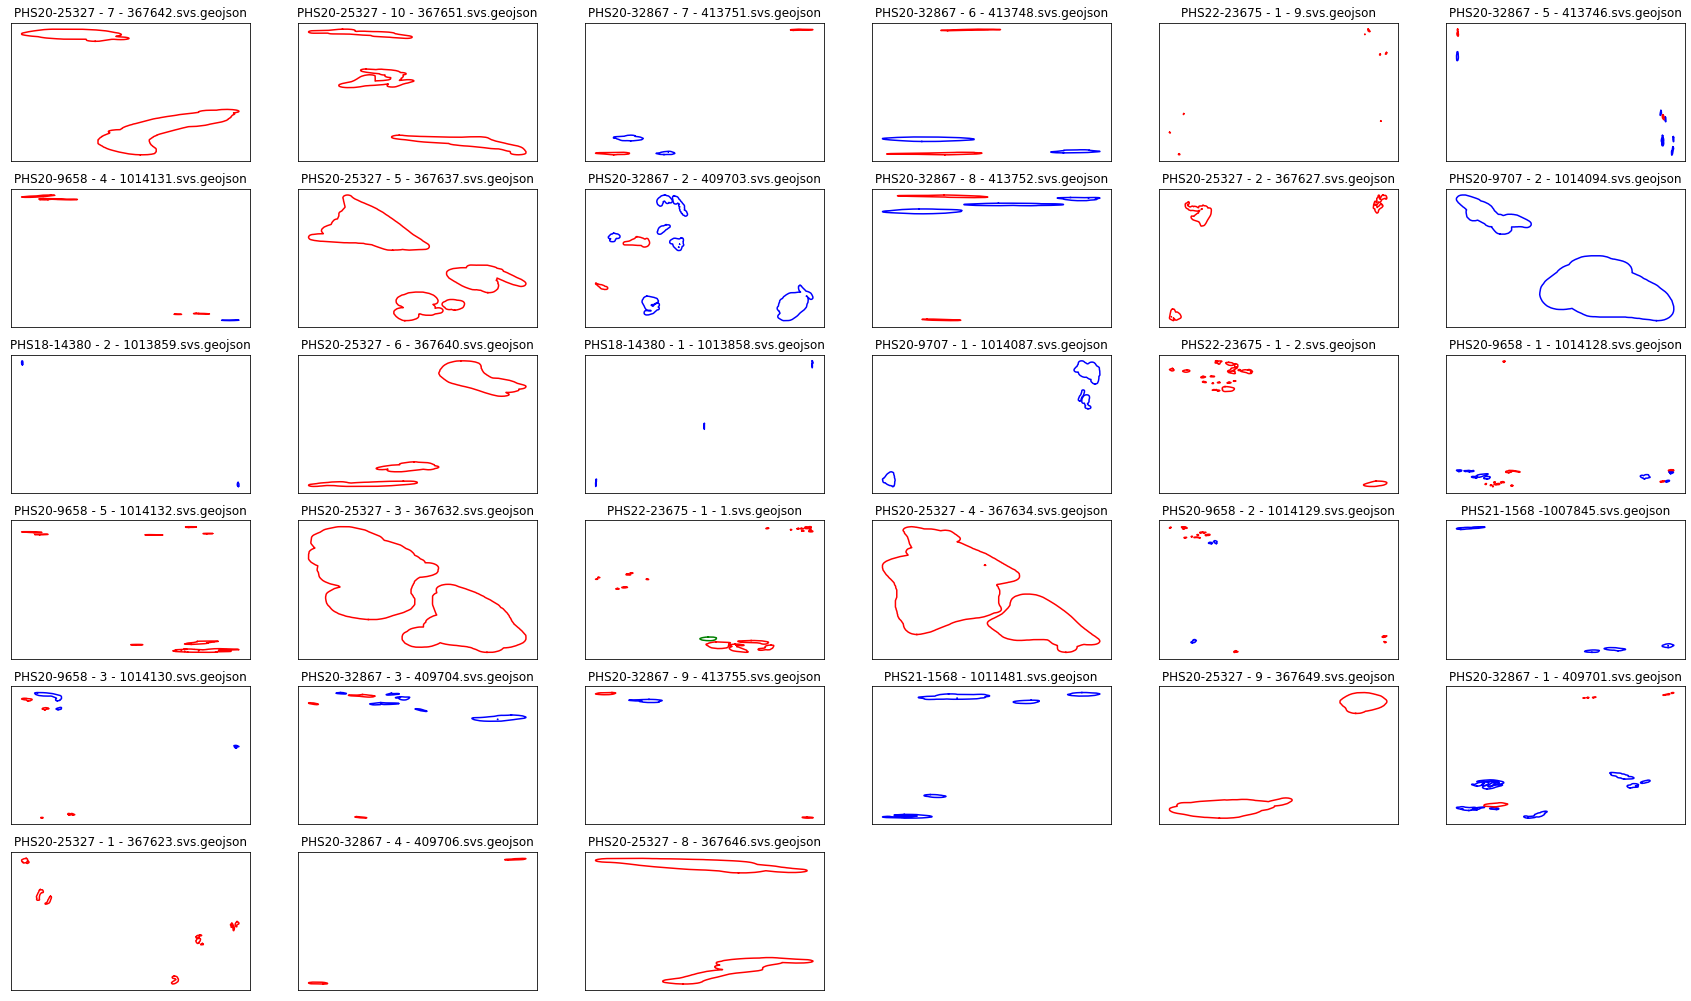

In [30]:
fig = plt.figure(figsize=(30,30))
i = 1
all_class = []
gjsons = [x for x in anno.joinpath('multi_slide_v0').rglob('*.geojson')]
class_cm = {'Tumor':'r', # New label in this set
            # 'Malignant':'r',
            'Benign Bile Duct':'b',
            }
for json_fname in gjsons:
    with open(json_fname) as f:
        allobjects = json.load(f) #
    ax = fig.add_subplot(10,6,i)
    ax.set_title(json_fname.parts[-1])
    for feat in allobjects['features']:
        annoHelper.plot_geojson_feature(feat,ax,
                                       class_cm = class_cm )
        plt.xticks([])
        plt.yticks([])
    i = i + 1
print(np.unique(all_class))
plt.savefig(anno.joinpath('aatur_qupath_new_annotations_120922.png'))
plt.savefig(results.joinpath('aatur_qupath_new_annotations_120922.png'))


# Example check if point in anno

Text(0.5, 1.0, 'Test area 75.0% in annotation.')

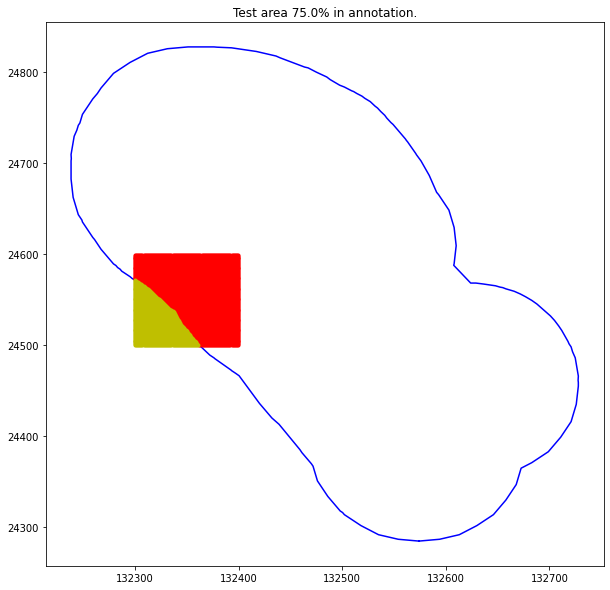

In [70]:
all_class = []
gjsons = [x for x in anno.rglob('*.geojson')]
for json_fname in gjsons[0:1]:
    with open(json_fname) as f:
        allobjects = json.load(f) #
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(1,1,1)
plot_geojson_feature(feat,ax)
polygon = feat['geometry']['coordinates']
points = [[132300,24300],[132500,24600]]
points = []
for y in range(24500,24600):
    for x in range(132300,132400):
        points.append([x,y])
in_poly = check_points_in_feature(feat,points)        
idxs = [ in_poly == True, in_poly ==False]
pa = np.array(points)
for i,idx in enumerate(idxs):
    xy=pa[idx,:]
    if i==0:
        ax.plot(xy[:,0],xy[:,1],'r.')
    else:
         ax.plot(xy[:,0],xy[:,1],'y.')
ax.set_title('Test area %2.1f%% in annotation.' % (np.sum(in_poly)/len(in_poly) * 100))
# plt.savefig(results.joinpath('example_tile_overlap_detect.png'))
# plt.savefig(anno.joinpath('example_tile_overlap_detect.png'))



In [50]:
math.sqrt((tile_size**2)*2)

316.7838379715733

In [72]:
tile_xy = [132300,24600]
tile_size = 224
print(check_tile_near_feature(feat,tile_xy,tile_size))

tile_xy =np.array( [132300,24600]) + 1000
tile_size = 224
check_tile_near_feature(feat,tile_xy,tile_size)

True


False

# For example folder of tiles check which tiles are in annotation

In [43]:
gjsons = [x for x in anno.rglob('*.geojson')]
# use = '1007826' #--> Works fine
# use = '1007733' # --> Initial run found 0 overlapping tiles
use = '1007832' # --> Second run also found 0 overlapping tiles?
i = info.slide_num==int(use)
svs = '%s.svs' % info.loc[i,'accession_number'].values[0]
print(svs,' -exists-->', raw.joinpath(svs).exists())
tpn = results.joinpath('v8/tiles/224px').joinpath(use)
print('Tile path exists:',tpn.exists())
for gpn in gjsons:
    if use in gpn.parts[-1]:
        json_fname = gpn
print(json_fname)
with open(json_fname) as f:
        allobjects = json.load(f) #
tiles = [x.parts[-1] for x in tpn.glob('*.jpg')]
tile_anno=pd.DataFrame(columns=['tile','x','y','feat','overlap'],data=np.zeros((len(tiles),5)))
tile_anno.tile=tiles
thresh= 10 #20 percent
i = 0
feat = allobjects['features'][i]
# for i,feat in enumerate(allobjects['features']):
for ii,fn in enumerate(tiles):
    n,x,y,size = annoHelper.parse_tile_fn(str(fn))
    if i==0:
        tile_anno.loc[ii,'x']=y
        tile_anno.loc[ii,'y']=x
    per_overlap = annoHelper.check_tile_overlap_feat(feat,[y,x],size)
    if per_overlap > thresh:
        if per_overlap > tile_anno.loc[ii,'overlap']: #To deal with cases with more than one annotation in a tile
            tile_anno.loc[ii,'feat']=i
            tile_anno.loc[ii,'overlap']=per_overlap
# print(tile_anno.overlap.unique())

tile_anno.head()

PHS17-9700 - 1007832.svs  -exists--> True
Tile path exists: True
/mnt/data/biliseq_he_class/annotations/malignant_v0/1007832.svs.geojson


,tile,x,y,feat,overlap
0,1007832_n51394_x8512_y19040_px224.jpg,19040.0,8512.0,0.0,0.0
1,1007832_n51741_x8512_y57904_px224.jpg,57904.0,8512.0,0.0,0.0
2,1007832_n41050_x6720_y68320_px224.jpg,68320.0,6720.0,0.0,0.0
3,1007832_n45001_x7392_y57904_px224.jpg,57904.0,7392.0,0.0,0.0
4,1007832_n85645_x14224_y5264_px224.jpg,5264.0,14224.0,0.0,0.0


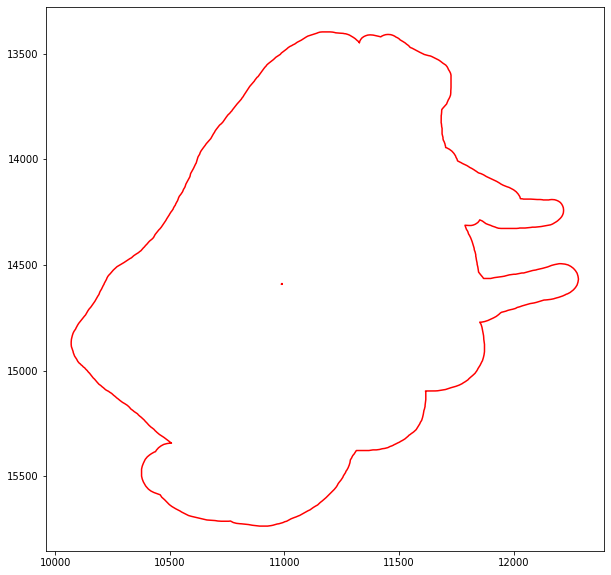

In [9]:
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(1,1,1)
plot_geojson_feature(feat,
                         ax)
ax.invert_yaxis()

(array([1037.,    0.,    0.,    0.,  775.,  284.,    0.,    0.,    0.,
        1054.]),
 array([  4144. ,  14963.2,  25782.4,  36601.6,  47420.8,  58240. ,
         69059.2,  79878.4,  90697.6, 101516.8, 112336. ]),
 <BarContainer object of 10 artists>)

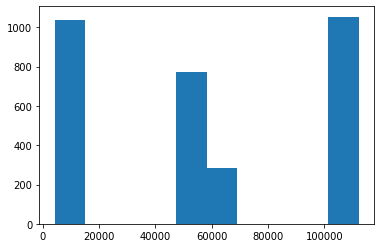

In [83]:
plt.hist(tile_anno.y)

In [94]:
np.argwhere(tile_anno.overlap.values > 50).flatten()

array([  28,  544, 1085, 1138, 1551, 1762, 1926, 1972, 2032, 2189, 2451,
       2468, 2676, 2737, 2779, 2782, 2942])

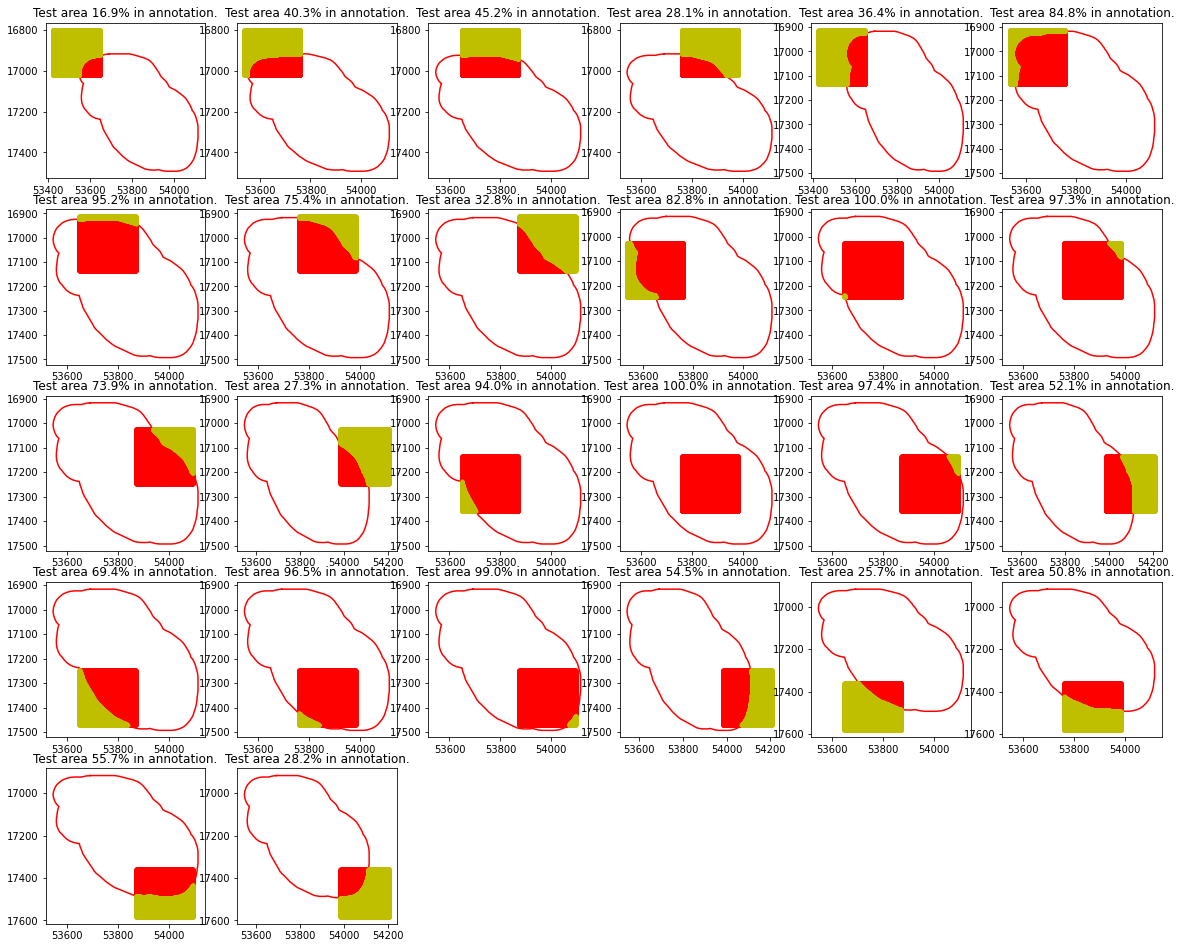

In [119]:
fig = plt.figure(figsize=(20,20))
idx = np.argwhere(tile_anno.overlap.values > 10).flatten()
tile_order=[]
for fn in tile_anno.tile[idx].values:
    n,x,y,size = parse_tile_fn(fn)
    tile_order.append(n)
ss = np.argsort(tile_order)
idx = idx[ss]
ii = 1
tile_size=224
for i in idx:
    ax = fig.add_subplot(6,6,ii)
    tile_xy=tile_anno.loc[i,['y','x']].values.astype(int)
    plot_tile_on_annotation(feat,tile_xy,tile_size,ax)
    # ax.invert_yaxis()
    # ax.invert_xaxis()
    ii = ii + 1
    
plt.savefig(results.joinpath('%s_feat_0_tile_overlap_detect.png' % use))
# plt.savefig(anno.joinpath('example_tile_overlap_detect.png'))

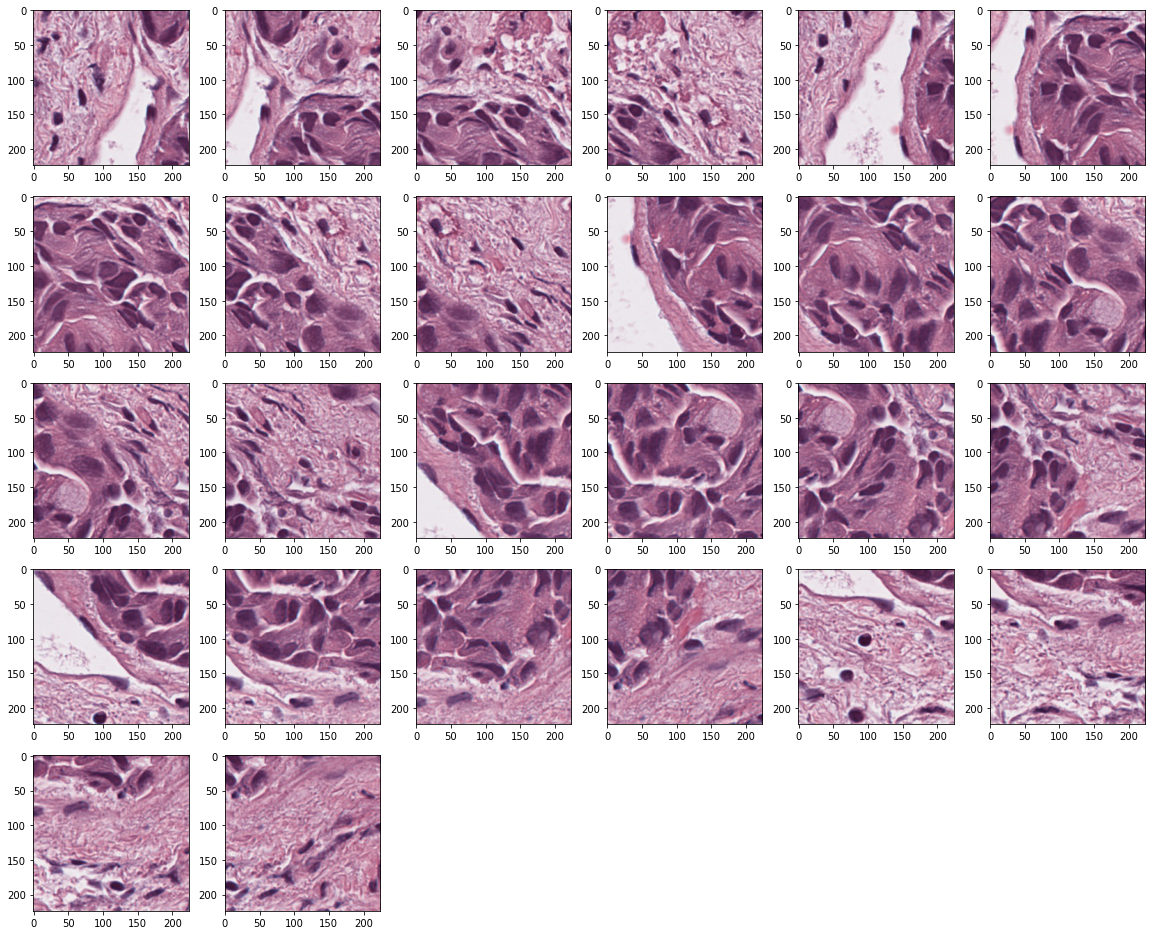

In [120]:
fig = plt.figure(figsize=(20,20))
ii = 1
tile_size=224
for i in idx:
    ax = fig.add_subplot(6,6,ii)
    tile_fn=tile_anno.loc[i,'tile']
    img = plt.imread(tpn.joinpath(tile_fn))
    ax.imshow(img,origin='upper')
    ii = ii + 1
plt.savefig(results.joinpath('%s_feat_0_tile_overlap_processed_tiles.png' % use))

# Run annotated tile selection on all annotated slides, time it

## See: preprocessing/anno_tile_overlap_v1.py and preprocessing/batch_tile_anno_job_v8.sh

## Worked example

In [16]:
gjsons = [x for x in anno.rglob('*.geojson')]
annotated_slides = [fn.parts[-1].split('.svs.geojson')[0] for fn in gjsons]
print(len(annotated_slides), 'annotated slides')
print(annotated_slides)
count = 0
bc = 0
malig = []
benign = []
for use in annotated_slides:
    idx1 = info.slide_num.str.contains(use)
    idx2 = info.accession_number.str.contains(use)
    if not np.any(idx1 | idx2):
        print('%s missing' % use)
    elif np.sum(idx1 | idx2) > 1:
        print('Warning %d different slide matches' % np.sum(idx1 | idx2))
    else:
        idx = idx1 | idx2
        diag = info.pathologic_diagnosis[idx].values
        # if not np.any(diag):
        #     print(use)
        if diag == 'Adenocarcinoma':
            count = count + 1
            malig.append(use)
        else:
            benign.append(use)
            bc += 1
print(count, 'malignant slides.', bc, ' benign slides')
# print(malig)

77 annotated slides
['1007476', '1007731', '1007482', '1007831', '1007733', '1007486', '1007827', '1007828', '1007484', '1010162', '1007829', '1010161', '1007826', '1007485', '1007832', '1007477', '1007478', '1007830', 'PHS20-25327 - 7 - 367642', 'PHS20-25327 - 10 - 367651', 'PHS20-32867 - 7 - 413751', 'PHS20-32867 - 6 - 413748', 'PHS22-23675 - 1 - 9', 'PHS20-32867 - 5 - 413746', 'PHS20-9658 - 4 - 1014131', 'PHS20-25327 - 5 - 367637', 'PHS20-32867 - 2 - 409703', 'PHS20-32867 - 8 - 413752', 'PHS20-25327 - 2 - 367627', 'PHS20-9707 - 2 - 1014094', 'PHS18-14380 - 2 - 1013859', 'PHS20-25327 - 6 - 367640', 'PHS18-14380 - 1 - 1013858', 'PHS20-9707 - 1 - 1014087', 'PHS22-23675 - 1 - 2', 'PHS20-9658 - 1 - 1014128', 'PHS20-9658 - 5 - 1014132', 'PHS20-25327 - 3 - 367632', 'PHS22-23675 - 1 - 1', 'PHS20-25327 - 4 - 367634', 'PHS20-9658 - 2 - 1014129', 'PHS21-1568 -1007845', 'PHS20-9658 - 3 - 1014130', 'PHS20-32867 - 3 - 409704', 'PHS20-32867 - 9 - 413755', 'PHS21-1568 - 1011481', 'PHS20-25327 - 9 -

In [44]:
thresh= 10 
fn = results.joinpath('malig_v8_224px_tiles_gt_%d_overlap_v1.tsv' % thresh)
# keep = pd.DataFrame([])

keep = pd.read_csv(fn,sep='\t').drop(columns='Unnamed: 0')
slide_nums = ['1007832']

tot_start = time.time()
annotated_slides = [fn.parts[-1].split('.svs.geojson')[0] for fn in gjsons]
dropped = []
for use in slide_nums:
    try:
        i = info.slide_num==int(use)
        svs = '%s.svs' % info.loc[i,'accession_number'].values[0]
        if raw.joinpath(svs).exists():
            print(svs,' -exists-->', raw.joinpath(svs).exists())
            tpn = results.joinpath('v8/tiles/224px').joinpath(use)
            for gpn in gjsons:
                if use in gpn.parts[-1]:
                    json_fname = gpn
            print(json_fname)
            with open(json_fname) as f:
                allobjects = json.load(f) #
            tiles = [x.parts[-1] for x in tpn.glob('*.jpg')]
            tile_anno=pd.DataFrame(columns=['tile','x','y','feat','overlap'],data=np.zeros((len(tiles),5)))
            tile_anno.tile=tiles           
            start = time.time()
            # if allobjects['features'][0]['properties']['classification']['name'] == 'Malignant':
            for i,feat in enumerate(allobjects['features']):            
                for ii,fn in enumerate(tiles):
                    n,x,y,size = annoHelper.parse_tile_fn(str(fn))
                    if i==0:
                        tile_anno.loc[ii,'x']=y
                        tile_anno.loc[ii,'y']=x
                    per_overlap = annoHelper.check_tile_overlap_feat(feat,[y,x],size)
                    if per_overlap > thresh:
                        if per_overlap > tile_anno.loc[ii,'overlap']: #To deal with cases with more than one annotation in a tile
                            tile_anno.loc[ii,'feat']=i
                            tile_anno.loc[ii,'overlap']=per_overlap
            keep = pd.concat((keep,tile_anno.loc[tile_anno.overlap > thresh,:]),axis=0)
            # else:
            #     print('Skipping non-malignant feature set based off feature 0 in file != "Malignant"')
            stop = time.time()
            print('Duration = %2.1f minutes' % ((stop-start)/60))
            print('%d overlapping tiles' % (np.sum(tile_anno.overlap > 10)))
        else:
            print(svs,'NOT FOUND!')
    except:
        dropped.append(svs)
        print('Error processing %s' % svs)
        
print('Total time = %3.1f minutes' % ((time.time()-tot_start)/60))
keep.loc[:,'slide']=np.stack(keep.tile.str.split('_'))[:,0]
fn = results.joinpath('malig_v8_224px_tiles_gt_%d_overlap_v2.tsv' % thresh)
print(fn)     
keep.to_csv(fn, sep = '\t')


PHS17-9700 - 1007832.svs  -exists--> True
/mnt/data/biliseq_he_class/annotations/malignant_v0/1007832.svs.geojson
Duration = 17.4 minutes
1053 overlapping tiles
Total time = 17.4 minutes
1007832_n65485_x10864_y11984_px224.jpg


In [44]:
fn = results.joinpath('malig_anno_v8_224px_tiles_gt_%d_overlap_v1.tsv' % thresh)
print(fn)                      
keep.to_csv(fn, sep = '\t')

(6758, 5)

## DEBUG - annotations throwing errors

In [ ]:
use = '1007484'
i = info.slide_num==int(use)
svs = '%s.svs' % info.loc[i,'accession_number'].values[0]
if raw.joinpath(svs).exists():
    print(svs,' -exists-->', raw.joinpath(svs).exists())
    tpn = results.joinpath('v8/tiles/224px').joinpath(use)
    for gpn in gjsons:
        if use in gpn.parts[-1]:
            json_fname = gpn
    print(json_fname)
    with open(json_fname) as f:
            allobjects = json.load(f) #
    tiles = [x.parts[-1] for x in tpn.glob('*.jpg')]
    tile_anno=pd.DataFrame(columns=['tile','x','y','feat','overlap'],data=np.zeros((len(tiles),5)))
    tile_anno.tile=tiles
    thresh= 10 
    start = time.time()
    if allobjects['features'][0]['properties']['classification']['name'] == 'Malignant':
        for i,feat in enumerate(allobjects['features'][2:]):     
            print('Feature',i)
            for ii,fn in enumerate(tiles):
                n,x,y,size = parse_tile_fn(str(fn))
                if i==0:
                    tile_anno.loc[ii,'x']=y
                    tile_anno.loc[ii,'y']=x
                per_overlap =  annoHelper.check_tile_overlap_feat(feat,[y,x],size)
                if per_overlap > thresh:
                    if per_overlap > tile_anno.loc[ii,'overlap']: #To deal with cases with more than one annotation in a tile
                        tile_anno.loc[ii,'feat']=i
                        tile_anno.loc[ii,'overlap']=per_overlap
        # keep = pd.concat((keep,tile_anno.loc[tile_anno.overlap > thresh,:]),axis=0)
    else:
        print('Skipping non-malignant featureset based off feature 0 in file != "Malignant"')
    stop = time.time()
    print('Duration = %2.1f minutes' % ((stop-start)/60))
    print('%d overlapping tiles' % (np.sum(tile_anno.overlap > 10)))
else:
    print(svs,'NOT FOUND!')



In [ ]:
pdb.pm()

# Read in overlapping annotated tile DF

## Merge individual files to one df and save

In [42]:
out = Path(results.joinpath('v8/anno'))
thresh=10
#Start with previously determined overlap files
keep = pd.read_csv('/mnt/results/v8/anno/malig_v8_224px_tiles_gt_10_overlap_v2.tsv',
                   sep = '\t') # pd.DataFrame([])
#Then add in new files:
for x in out.rglob("*v3.tsv"):
    dat = pd.read_csv(x,sep='\t')
    keep = pd.concat((keep,dat),axis=0)
keep=keep.reset_index(drop=True)
print(keep.shape)
new_fn = 'merged_v8_%d_224px_tiles_gt_%d_overlap_v3.tsv' % (keep.shape[0],
                                                           thresh)
pnfn = results.joinpath('v8/anno').joinpath(new_fn)
print(pnfn)
keep.to_csv(pnfn,
            sep='\t',
            index=False,
           )
keep.tail()

(25636, 7)
/mnt/results/v8/anno/merged_v8_25636_224px_tiles_gt_10_overlap_v3.tsv


,Unnamed: 0,tile,x,y,feat,overlap,slide
25631,13280,367632_n118932_x13104_y59136_px224.jpg,59136.0,13104.0,0.0,100.000000,367632
25632,13303,367632_n119944_x13216_y59136_px224.jpg,59136.0,13216.0,0.0,100.000000,367632
25633,13428,367632_n114886_x12656_y59360_px224.jpg,59360.0,12656.0,0.0,100.000000,367632
25634,13615,367632_n112866_x12432_y59808_px224.jpg,59808.0,12432.0,1.0,83.360571,367632
25635,13657,367632_n116909_x12880_y59248_px224.jpg,59248.0,12880.0,0.0,100.000000,367632


## Load a merged df

In [44]:
thresh = 10
fn = '/mnt/results/v8/anno/merged_v8_25636_224px_tiles_gt_10_overlap_v3.tsv'
malig = pd.read_csv(fn,sep='\t').drop(columns='Unnamed: 0')
malig.shape
malig.head()

,tile,x,y,feat,overlap,slide
0,1007476_n70400_x4928_y93632_px224.jpg,93632.0,4928.0,15.0,49.784758,1007476
1,1007476_n203212_x14336_y94528_px224.jpg,94528.0,14336.0,6.0,72.498804,1007476
2,1007476_n231655_x16352_y92848_px224.jpg,92848.0,16352.0,34.0,14.437181,1007476
3,1007476_n64071_x4480_y93072_px224.jpg,93072.0,4480.0,16.0,79.127471,1007476
4,1007476_n230069_x16240_y92288_px224.jpg,92288.0,16240.0,34.0,39.688297,1007476
